# 02 — 探索性数据分析 (EDA)

**目标**: 从多个维度分析销售数据，发现商业洞察。

**分析框架**:
1. 时间趋势 — 销售额 & 利润如何随时间变化？
2. 品类分析 — 什么产品最赚钱？帕累托分析
3. 地理分析 — 哪个区域/州表现最好？
4. 折扣分析 — 折扣策略有效吗？
5. 客户分群 — 不同客群的消费行为差异
6. 运输分析 — 运输方式偏好 & 时效

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 120

# 自定义调色板
PALETTE = sns.color_palette('Set2', 8)

print('Libraries loaded.')

Libraries loaded.


In [15]:
# 加载清洗后数据
df = pd.read_csv('../data/Superstore_Cleaned.csv', parse_dates=['Order Date', 'Ship Date'])
print(f'Loaded: {len(df)} rows, {df["Order ID"].nunique()} orders')
df.head(2)

Loaded: 2029 rows, 1098 orders


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Order Year,Order Month,Order Quarter,Order Month Name,Order Day of Week,Order Day Name,Processing Days,Is Profitable,Discount Tier,Profit Margin
0,1,US-0365,2020-01-03,2020-01-06,First Class,CG-00284,Customer 284,Home Office,United States,Colorado,...,2020,1,1,Jan,4,Friday,3,True,Low (0-10%),10.38
1,2,US-0217,2020-01-03,2020-01-05,First Class,CG-00295,Customer 295,Home Office,United States,Minnesota,...,2020,1,1,Jan,4,Friday,2,True,No Discount,34.27


---
## 一、时间趋势分析

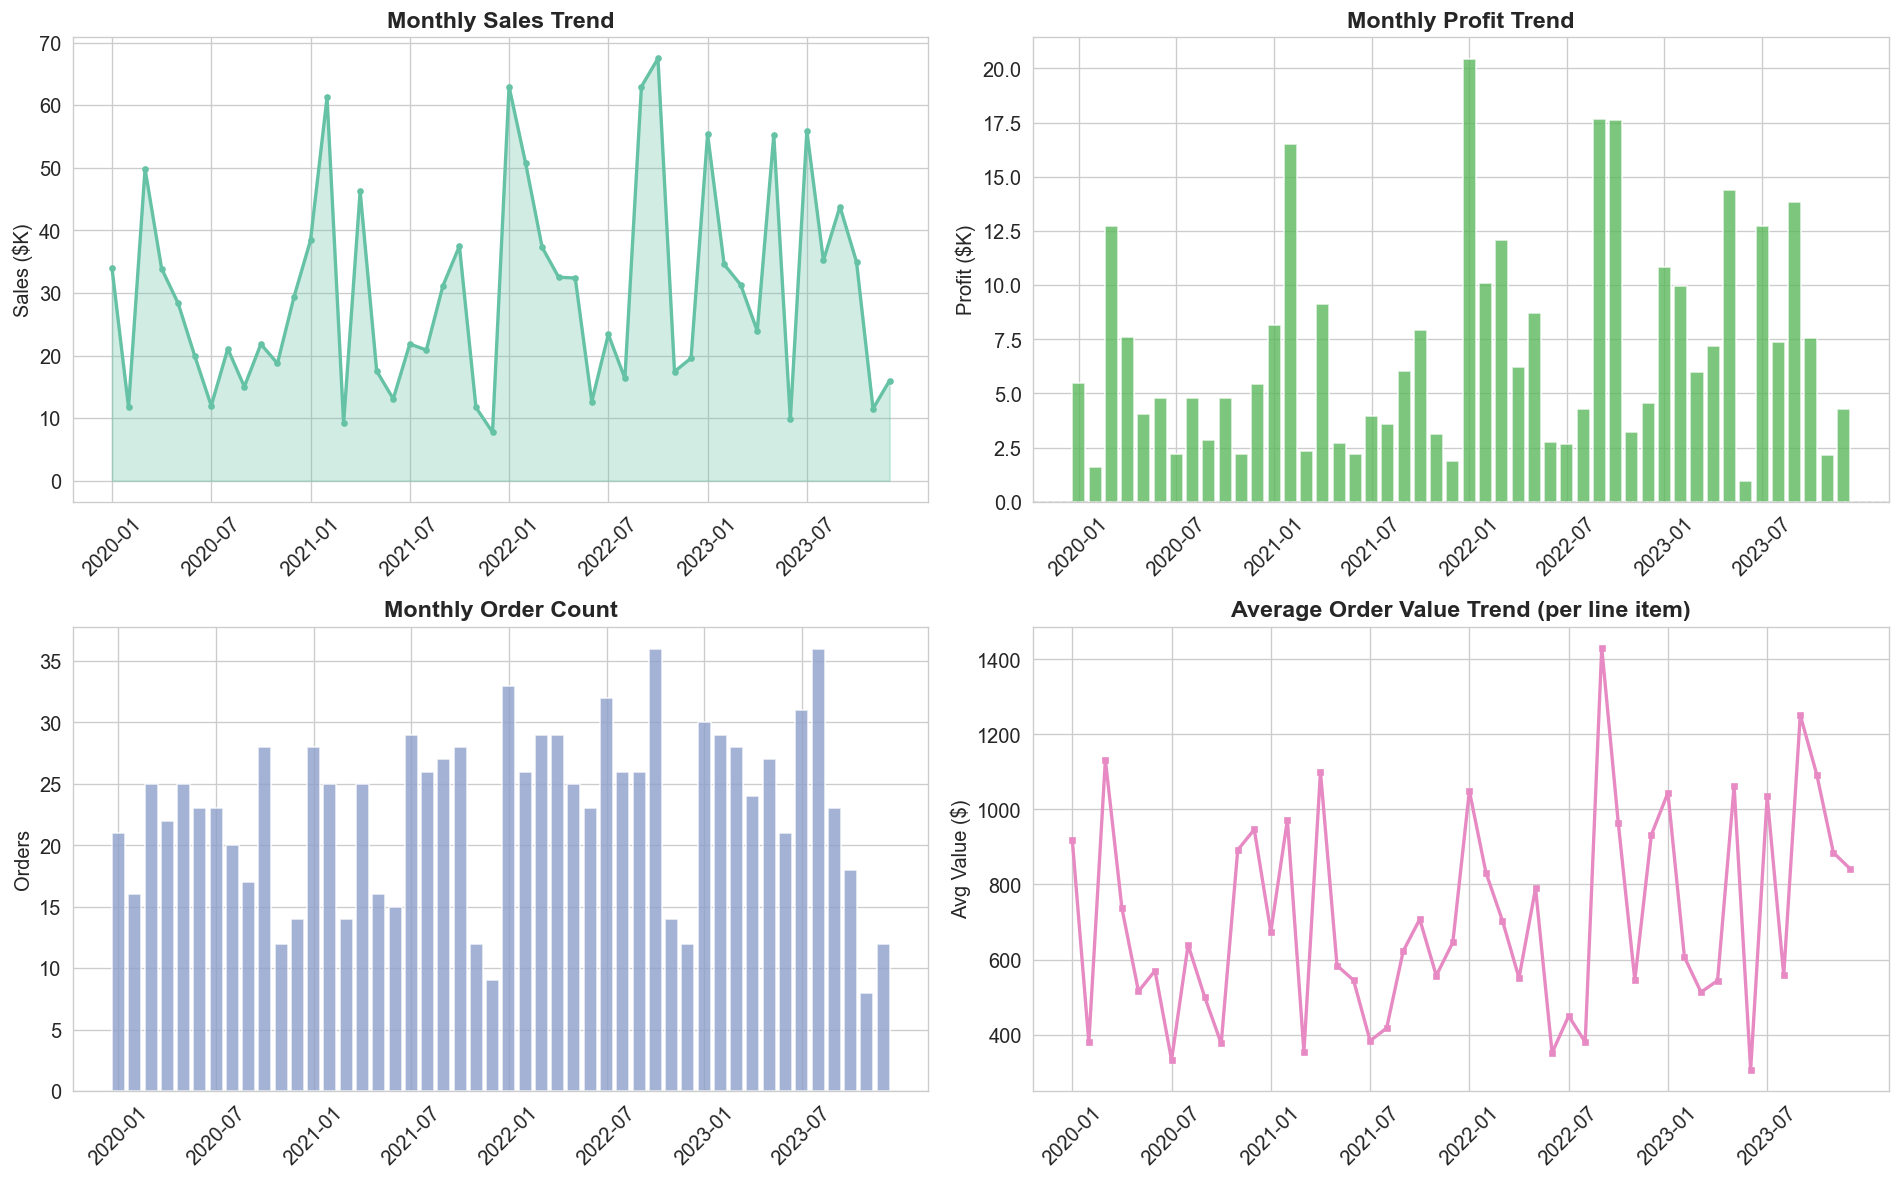

月均销售额: $30,316
月均利润: $6,955
最高销售月: 2022-10 ($67,455)


In [16]:
# ========== 月度销售 & 利润趋势 ==========
monthly = df.groupby(['Order Year', 'Order Month', 'Order Month Name']).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Avg_Order_Value=('Sales', 'mean')
).reset_index()
monthly['Date'] = pd.to_datetime(
    monthly['Order Year'].astype(str) + '-' + monthly['Order Month'].astype(str) + '-01'
)
monthly = monthly.sort_values('Date')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 销售额趋势
ax = axes[0, 0]
ax.fill_between(range(len(monthly)), monthly['Sales']/1000, alpha=0.3, color=PALETTE[0])
ax.plot(range(len(monthly)), monthly['Sales']/1000, marker='o', color=PALETTE[0], linewidth=2, markersize=3)
ax.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Sales ($K)')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly['Date'].iloc[::6]], rotation=45)

# 2. 利润趋势
ax = axes[0, 1]
colors = ['#d9534f' if p < 0 else '#5cb85c' for p in monthly['Profit']/1000]
ax.bar(range(len(monthly)), monthly['Profit']/1000, color=colors, alpha=0.8)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Monthly Profit Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Profit ($K)')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly['Date'].iloc[::6]], rotation=45)

# 3. 订单量趋势
ax = axes[1, 0]
ax.bar(range(len(monthly)), monthly['Orders'], color=PALETTE[2], alpha=0.8)
ax.set_title('Monthly Order Count', fontsize=14, fontweight='bold')
ax.set_ylabel('Orders')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly['Date'].iloc[::6]], rotation=45)

# 4. 客单价趋势
ax = axes[1, 1]
ax.plot(range(len(monthly)), monthly['Avg_Order_Value'], marker='s', color=PALETTE[3], linewidth=2, markersize=3)
ax.set_title('Average Order Value Trend (per line item)', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Value ($)')
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly['Date'].iloc[::6]], rotation=45)

plt.tight_layout()
plt.savefig('../reports/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'月均销售额: ${monthly["Sales"].mean():,.0f}')
print(f'月均利润: ${monthly["Profit"].mean():,.0f}')
print(f'最高销售月: {monthly.loc[monthly["Sales"].idxmax(), "Date"].strftime("%Y-%m")} (${monthly["Sales"].max():,.0f})')

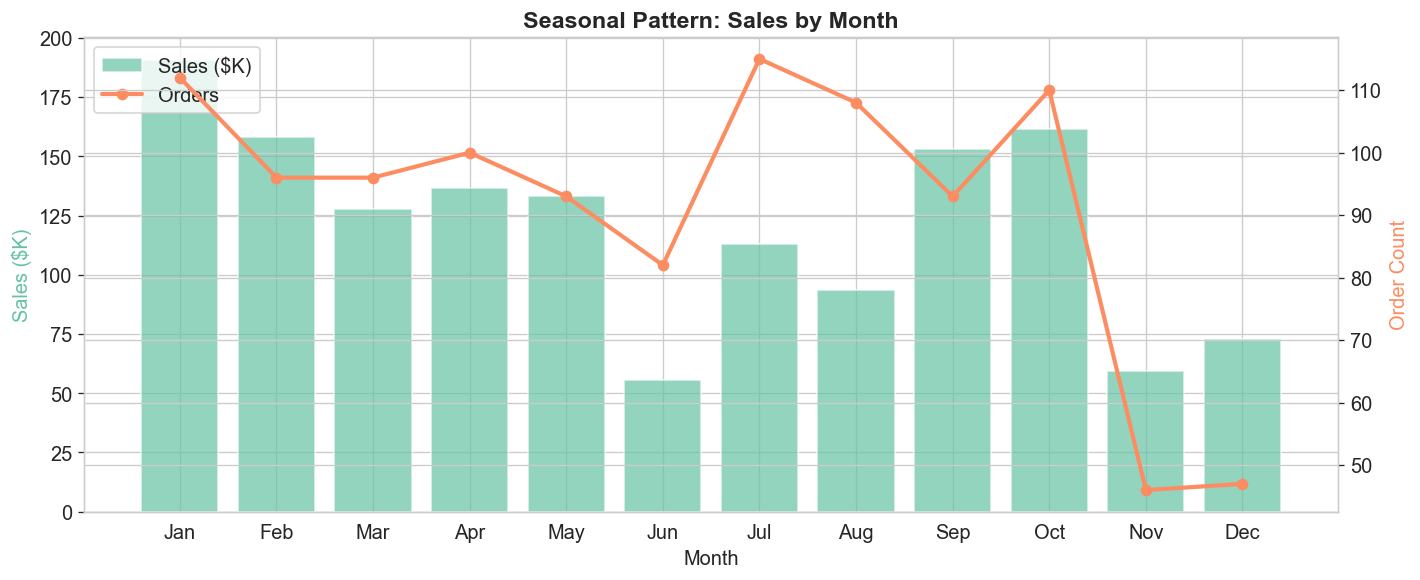


=== 季度销售额 ($K) ===
Order Quarter      1     2      3      4
Order Year                              
2020            95.6  82.2   48.1   69.9
2021           108.8  76.8   73.8   56.9
2022           151.0  77.5  102.7  104.5
2023           121.2  88.9  134.8   62.5


In [17]:
# ========== 季节性分析 ==========
seasonal = df.groupby('Order Month').agg(
    Sales=('Sales', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
months_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax1.bar(seasonal['Order Month'], seasonal['Sales']/1000, color=PALETTE[0], alpha=0.7, label='Sales ($K)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Sales ($K)', color=PALETTE[0])
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months_short)
ax1.set_title('Seasonal Pattern: Sales by Month', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(seasonal['Order Month'], seasonal['Orders'], marker='o', color=PALETTE[1], 
         linewidth=2.5, label='Orders')
ax2.set_ylabel('Order Count', color=PALETTE[1])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../reports/seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算同比季度增长
quarterly = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum().unstack()
print('\n=== 季度销售额 ($K) ===')
print((quarterly / 1000).round(1).to_string())

---
## 二、品类 & 产品分析

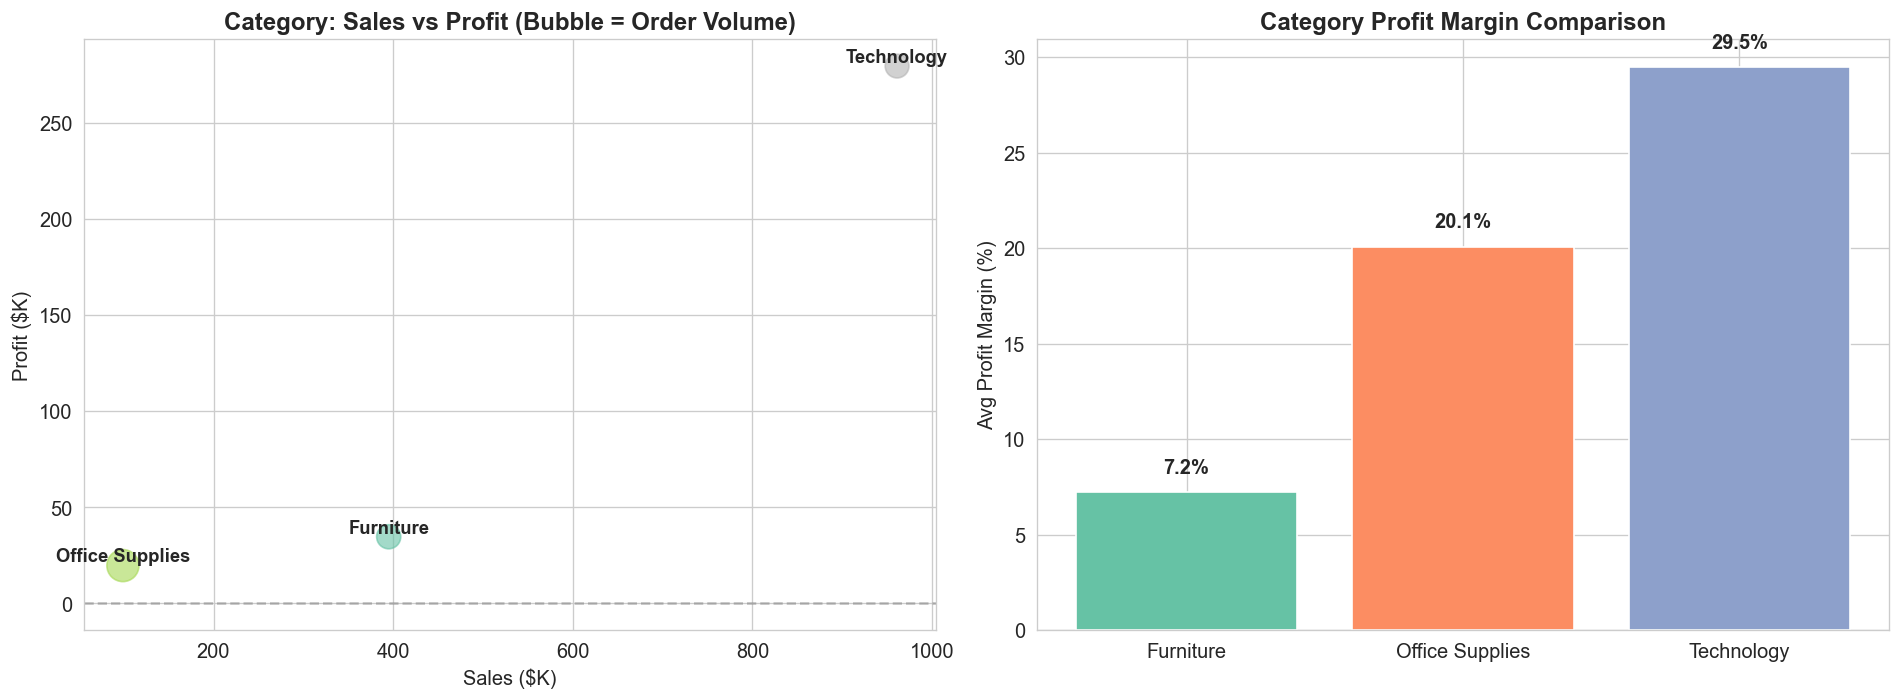

          Category      Sales     Profit  Orders  Profit_Margin
0        Furniture  395029.22   34625.15     418       7.223890
1  Office Supplies   99111.56   19627.26     741      20.081070
2       Technology  961035.49  279578.40     406      29.458288


In [18]:
# ========== 品类 Sales vs Profit（气泡图） ==========
cat_stats = df.groupby('Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Profit_Margin=('Profit Margin', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 成交额 vs 利润气泡图
ax = axes[0]
scatter = ax.scatter(
    cat_stats['Sales']/1000, cat_stats['Profit']/1000,
    s=cat_stats['Orders']/2, alpha=0.6, c=range(len(cat_stats)), cmap='Set2'
)
for _, row in cat_stats.iterrows():
    ax.annotate(row['Category'], (row['Sales']/1000, row['Profit']/1000),
                fontsize=11, ha='center', va='bottom', fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Sales ($K)')
ax.set_ylabel('Profit ($K)')
ax.set_title('Category: Sales vs Profit (Bubble = Order Volume)', fontweight='bold')

# 利润率对比
ax = axes[1]
bars = ax.bar(cat_stats['Category'], cat_stats['Profit_Margin'], 
              color=[PALETTE[i] for i in range(3)])
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_title('Category Profit Margin Comparison', fontweight='bold')
for bar, val in zip(bars, cat_stats['Profit_Margin']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_stats.to_string())

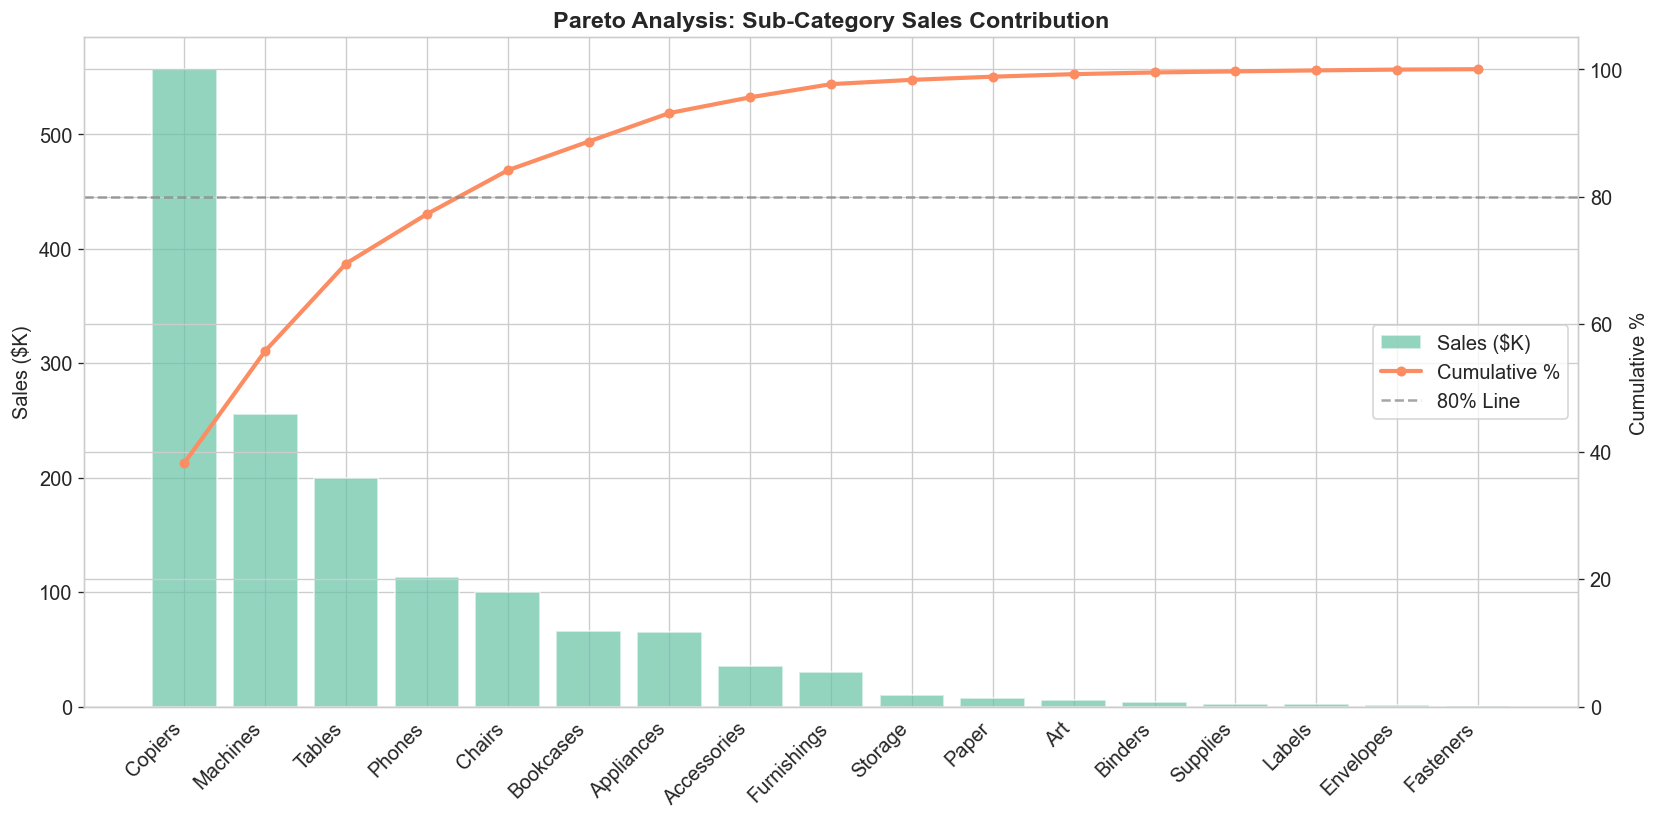

4/17 子品类贡献了 80% 的销售额:
Sub-Category     Sales    Profit  Sales_Cum_Pct
     Copiers 556787.67 162152.61      38.262558
    Machines 255398.91  72966.04      55.813622
      Tables 199424.89  17272.14      69.518140
      Phones 112933.79  34249.33      77.278972


In [19]:
# ========== 子品类帕累托分析 (80/20 法则) ==========
subcat = df.groupby('Sub-Category').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).sort_values('Sales', ascending=False).reset_index()

subcat['Sales_Cum_Pct'] = subcat['Sales'].cumsum() / subcat['Sales'].sum() * 100
subcat['Profit_Cum_Pct'] = subcat['Profit'].cumsum() / subcat['Profit'].sum() * 100

fig, ax = plt.subplots(figsize=(14, 7))

# 柱状图：销售额
bars = ax.bar(range(len(subcat)), subcat['Sales']/1000, color=PALETTE[0], alpha=0.7, label='Sales ($K)')

# 对亏损子品类标红
for i, (_, row) in enumerate(subcat.iterrows()):
    if row['Profit'] < 0:
        bars[i].set_color('#d9534f')
        bars[i].set_alpha(0.8)

ax.set_xticks(range(len(subcat)))
ax.set_xticklabels(subcat['Sub-Category'], rotation=45, ha='right')
ax.set_ylabel('Sales ($K)')

# 累计百分比线
ax2 = ax.twinx()
ax2.plot(range(len(subcat)), subcat['Sales_Cum_Pct'], marker='o', color=PALETTE[1], 
         linewidth=2.5, markersize=5, label='Cumulative %')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% Line')
ax2.set_ylabel('Cumulative %')
ax2.set_ylim(0, 105)

ax.set_title('Pareto Analysis: Sub-Category Sales Contribution', fontsize=14, fontweight='bold')

# 合并图例
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.savefig('../reports/pareto_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()

# 找出占 80% 销售额的子品类
top_80 = subcat[subcat['Sales_Cum_Pct'] <= 80]
print(f'{len(top_80)}/{len(subcat)} 子品类贡献了 80% 的销售额:')
print(top_80[['Sub-Category', 'Sales', 'Profit', 'Sales_Cum_Pct']].to_string(index=False))

In [20]:
# ========== 交互式: Plotly 树状图 ==========
fig = px.treemap(
    df, 
    path=['Category', 'Sub-Category'], 
    values='Sales', 
    color='Profit', 
    color_continuous_scale='RdYlGn',
    title='Sales & Profit Treemap: Category → Sub-Category'
)
fig.update_traces(textinfo='label+value+percent root')
fig.show()

---
## 三、地理 & 区域分析

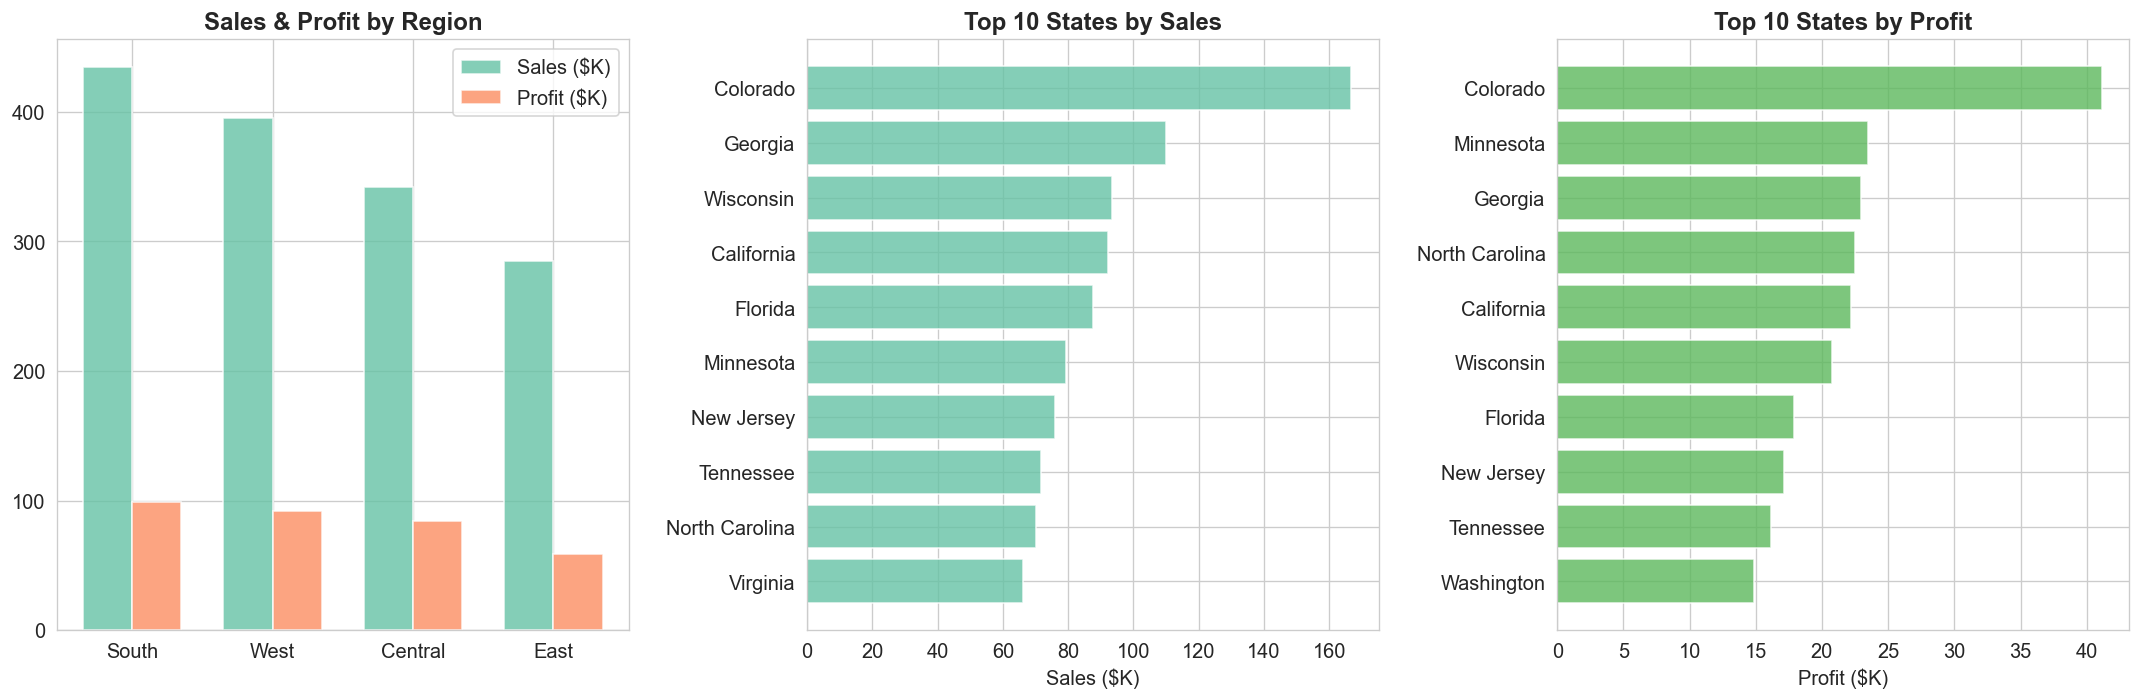

=== 区域汇总 ===
    Region      Sales    Profit  Orders  Customers  Profit_Margin
0    South  434107.56  98976.22     289         99      18.922860
1     West  394716.45  91913.03     276         93      19.815761
2  Central  341441.71  83945.27     260         90      19.297661
3     East  284910.55  58996.29     273         93      18.649731

表现最差的区域 (利润率最低): East


In [22]:
# ========== 区域 & 州分析 ==========
region_stats = df.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Profit_Margin=('Profit Margin', 'mean')
).sort_values('Sales', ascending=False).reset_index()

# Top 10 州
state_stats = df.groupby('State').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).assign(Profit_Margin=lambda x: (x['Profit'] / x['Sales'] * 100).round(1))
top_states_sales = state_stats.sort_values('Sales', ascending=False).head(10)
top_states_profit = state_stats.sort_values('Profit', ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 区域对比
ax = axes[0]
x = range(len(region_stats))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], region_stats['Sales']/1000, width, 
               color=PALETTE[0], alpha=0.8, label='Sales ($K)')
bars2 = ax.bar([i + width/2 for i in x], region_stats['Profit']/1000, width, 
               color=PALETTE[1], alpha=0.8, label='Profit ($K)')
ax.set_xticks(x)
ax.set_xticklabels(region_stats['Region'])
ax.set_title('Sales & Profit by Region', fontweight='bold')
ax.legend()

# Top 10 州 (Sales)
ax = axes[1]
ax.barh(range(len(top_states_sales)), top_states_sales['Sales']/1000, color=PALETTE[0], alpha=0.8)
ax.set_yticks(range(len(top_states_sales)))
ax.set_yticklabels(top_states_sales.index)
ax.invert_yaxis()
ax.set_xlabel('Sales ($K)')
ax.set_title('Top 10 States by Sales', fontweight='bold')

# Top 10 州 (Profit)
ax = axes[2]
colors = ['#d9534f' if p < 0 else '#5cb85c' for p in top_states_profit['Profit']/1000]
ax.barh(range(len(top_states_profit)), top_states_profit['Profit']/1000, color=colors, alpha=0.8)
ax.set_yticks(range(len(top_states_profit)))
ax.set_yticklabels(top_states_profit.index)
ax.invert_yaxis()
ax.set_xlabel('Profit ($K)')
ax.set_title('Top 10 States by Profit', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/geographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== 区域汇总 ===')
print(region_stats.to_string())
print(f'\n表现最差的区域 (利润率最低): {region_stats.loc[region_stats["Profit_Margin"].idxmin(), "Region"]}')

---
## 四、折扣与利润分析

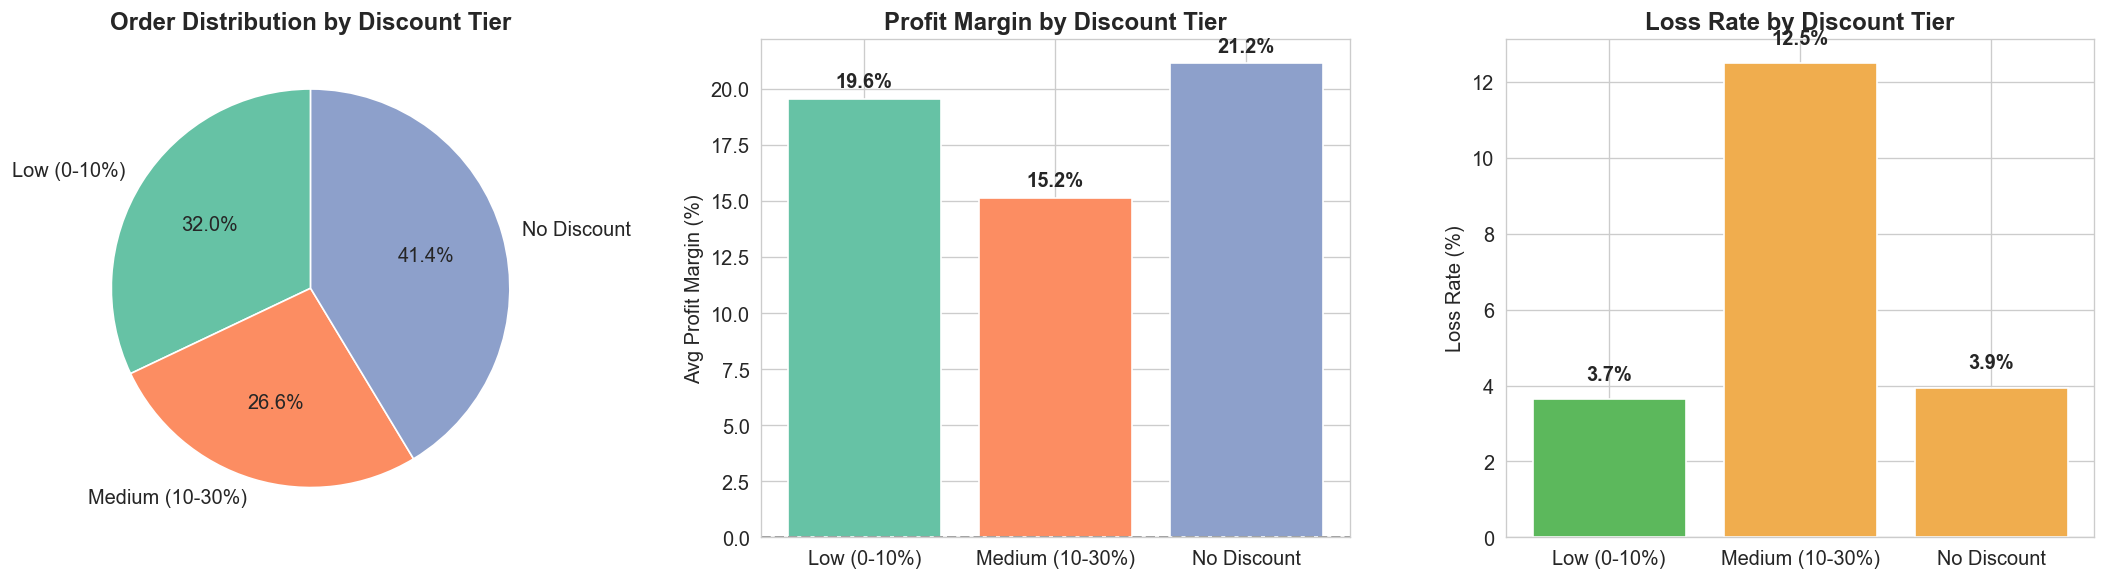

=== 折扣层级汇总 ===
     Discount Tier  Orders      Sales     Profit  Avg_Profit_Margin  Loss_Rate
0      Low (0-10%)     506  308755.58   73328.15          19.572984   3.650794
1  Medium (10-30%)     420  325362.23   63729.23          15.158223  12.500000
2      No Discount     653  821058.46  196773.43          21.166911   3.945885


In [23]:
# ========== 折扣层级分析 ==========
discount_stats = df.groupby('Discount Tier', observed=False).agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin', 'mean'),
    Loss_Rate=('Is Profitable', lambda x: (~x).mean() * 100)
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 折扣层级 — 订单分布
ax = axes[0]
ax.pie(discount_stats['Orders'], labels=discount_stats['Discount Tier'], 
       autopct='%1.1f%%', colors=sns.color_palette('Set2', 4), startangle=90)
ax.set_title('Order Distribution by Discount Tier', fontweight='bold')

# 平均利润率
ax = axes[1]
bars = ax.bar(discount_stats['Discount Tier'], discount_stats['Avg_Profit_Margin'], 
              color=PALETTE[:4])
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_title('Profit Margin by Discount Tier', fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--')
for bar, val in zip(bars, discount_stats['Avg_Profit_Margin']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
            ha='center', fontweight='bold')

# 亏损率
ax = axes[2]
bars = ax.bar(discount_stats['Discount Tier'], discount_stats['Loss_Rate'], 
              color=['#5cb85c', '#f0ad4e', '#f0ad4e', '#d9534f'])
ax.set_ylabel('Loss Rate (%)')
ax.set_title('Loss Rate by Discount Tier', fontweight='bold')
for bar, val in zip(bars, discount_stats['Loss_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/discount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== 折扣层级汇总 ===')
print(discount_stats.to_string())

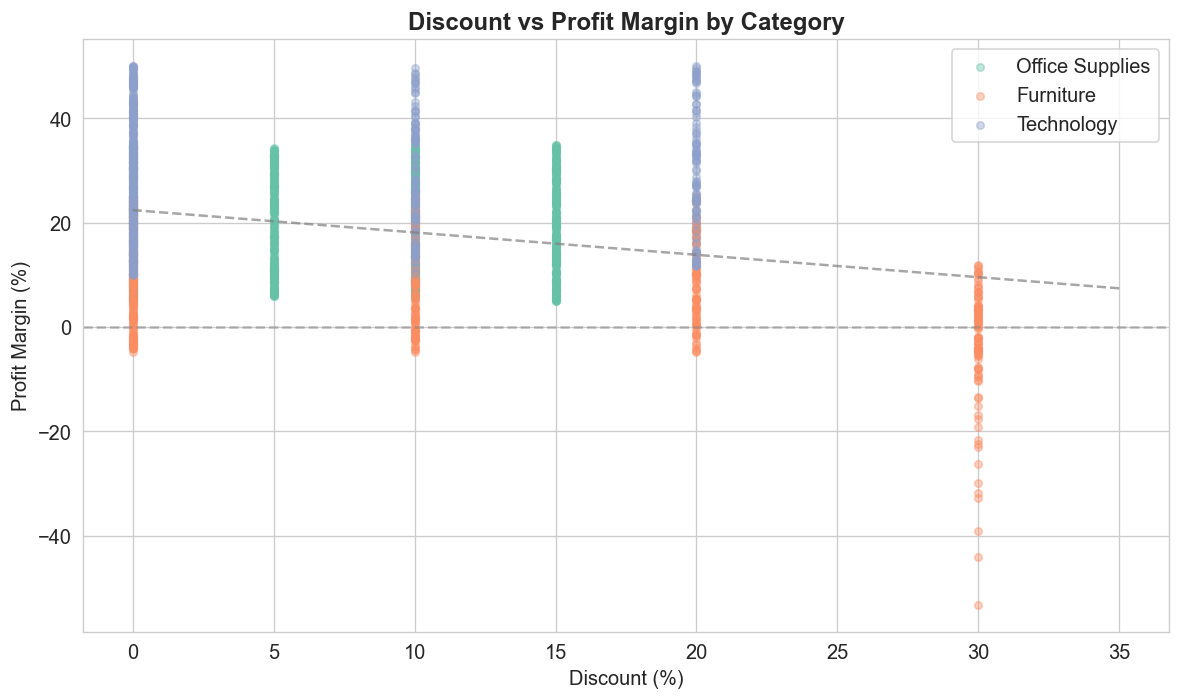

Discount 与 Profit Margin 相关系数: -0.286


In [24]:
# ========== 折扣 vs 利润率散点图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

categories = df['Category'].unique()
for i, cat in enumerate(categories):
    subset = df[df['Category'] == cat]
    ax.scatter(subset['Discount']*100, subset['Profit Margin'], 
              alpha=0.4, s=20, color=PALETTE[i], label=cat)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Profit Margin (%)')
ax.set_title('Discount vs Profit Margin by Category', fontweight='bold')
ax.legend()

# 添加趋势线
z = np.polyfit(df['Discount']*100, df['Profit Margin'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 35, 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.7, label='Overall Trend')

plt.tight_layout()
plt.savefig('../reports/discount_vs_margin.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df['Discount'].corr(df['Profit Margin'])
print(f'Discount 与 Profit Margin 相关系数: {corr:.3f}')

---
## 五、客户分群分析

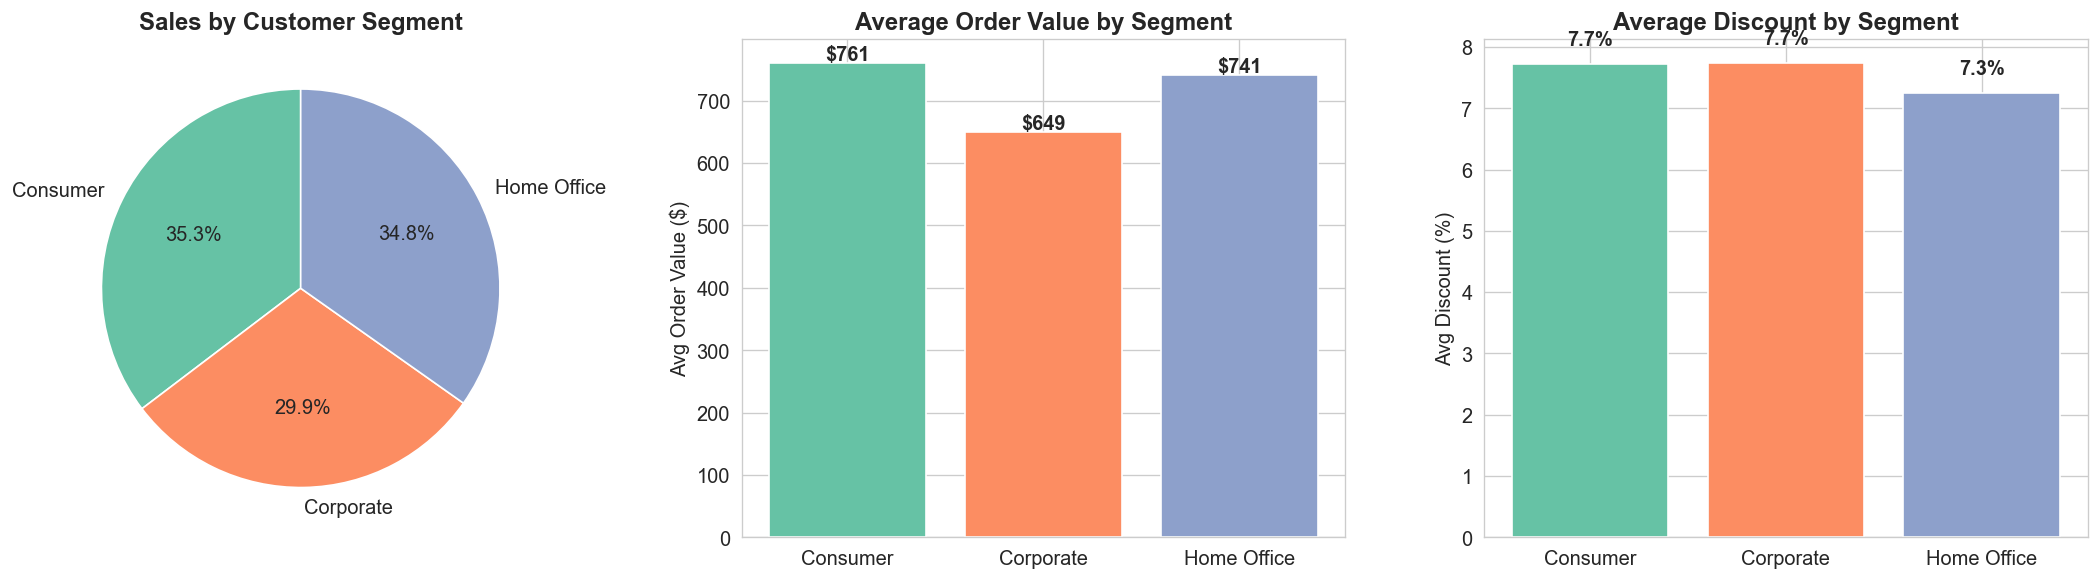

       Segment      Sales     Profit  Customers  Orders  Avg_Order_Value  Avg_Discount
0     Consumer  514147.61  119777.88        119     355       760.573388      0.077293
1    Corporate  434898.82  108280.60        131     373       649.102716      0.077388
2  Home Office  506129.84  105772.33        125     370       741.039297      0.072548


In [25]:
# ========== 客户细分 ==========
segment_stats = df.groupby('Segment').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Customers=('Customer ID', 'nunique'),
    Orders=('Order ID', 'nunique'),
    Avg_Order_Value=('Sales', 'mean'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 客群 Sales 占比
ax = axes[0]
ax.pie(segment_stats['Sales'], labels=segment_stats['Segment'], 
       autopct='%1.1f%%', colors=PALETTE[:3], startangle=90)
ax.set_title('Sales by Customer Segment', fontweight='bold')

# 客单价对比
ax = axes[1]
bars = ax.bar(segment_stats['Segment'], segment_stats['Avg_Order_Value'], color=PALETTE[:3])
ax.set_ylabel('Avg Order Value ($)')
ax.set_title('Average Order Value by Segment', fontweight='bold')
for bar, val in zip(bars, segment_stats['Avg_Order_Value']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'${val:.0f}',
            ha='center', fontweight='bold')

# 平均折扣
ax = axes[2]
bars = ax.bar(segment_stats['Segment'], segment_stats['Avg_Discount']*100, color=PALETTE[:3])
ax.set_ylabel('Avg Discount (%)')
ax.set_title('Average Discount by Segment', fontweight='bold')
for bar, val in zip(bars, segment_stats['Avg_Discount']*100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(segment_stats.to_string())

---
## 六、运输分析

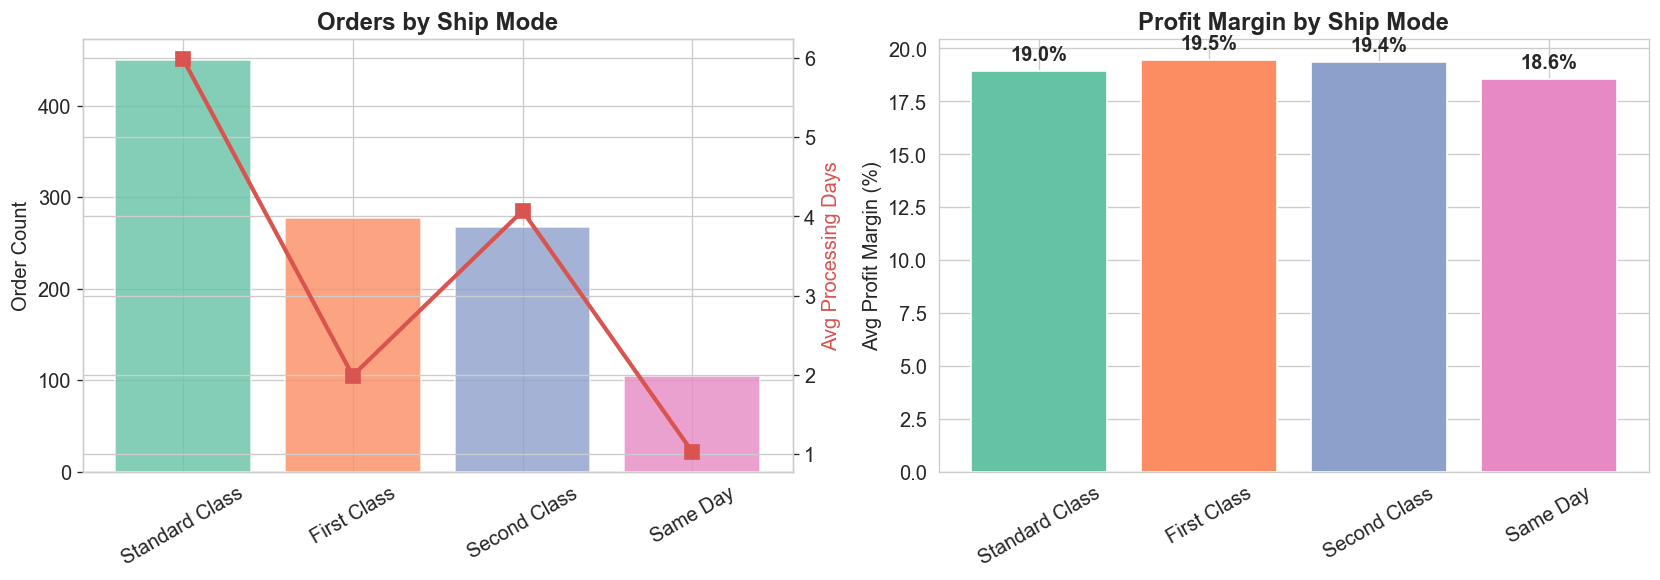

        Ship Mode  Orders      Sales  Avg_Processing_Days  Avg_Profit_Margin
0  Standard Class     450  597479.79             5.987700          18.955338
1     First Class     277  319653.24             1.990385          19.464385
2    Second Class     267  359545.10             4.068359          19.373887
3        Same Day     104  178498.14             1.027174          18.562174


In [26]:
# ========== 运输方式分析 ==========
ship_stats = df.groupby('Ship Mode').agg(
    Orders=('Order ID', 'nunique'),
    Sales=('Sales', 'sum'),
    Avg_Processing_Days=('Processing Days', 'mean'),
    Avg_Profit_Margin=('Profit Margin', 'mean')
).sort_values('Orders', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 订单量 & 平均处理天数
ax = axes[0]
bars = ax.bar(ship_stats['Ship Mode'], ship_stats['Orders'], color=PALETTE[:4], alpha=0.8)
ax.set_ylabel('Order Count')
ax.set_title('Orders by Ship Mode', fontweight='bold')
ax.tick_params(axis='x', rotation=30)

ax2 = ax.twinx()
ax2.plot(ship_stats['Ship Mode'], ship_stats['Avg_Processing_Days'], 
         marker='s', color='#d9534f', linewidth=2.5, markersize=8)
ax2.set_ylabel('Avg Processing Days', color='#d9534f')

# 利润率
ax = axes[1]
bars = ax.bar(ship_stats['Ship Mode'], ship_stats['Avg_Profit_Margin'], color=PALETTE[:4])
ax.set_ylabel('Avg Profit Margin (%)')
ax.set_title('Profit Margin by Ship Mode', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, ship_stats['Avg_Profit_Margin']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/shipping_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(ship_stats.to_string())

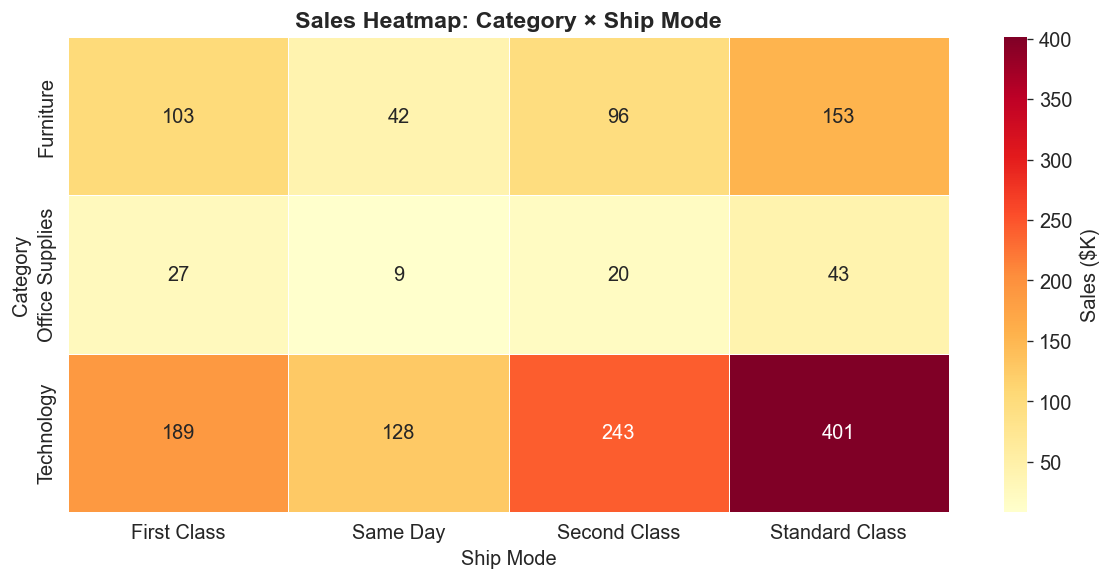

In [27]:
# ========== 品类 × 运输方式 热力图 ==========
pivot_ship = df.pivot_table(
    values='Sales', index='Category', columns='Ship Mode', aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_ship/1000, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Sales ($K)'})
ax.set_title('Sales Heatmap: Category × Ship Mode', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/category_ship_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## EDA 关键发现汇总

| # | 发现 | 业务建议 |
|---|------|---------|
| 1 | Technology 品类利润率最高 | 加大 Tech 产品营销投入 |
| 2 | Q4 是销售旺季 | 提前备货，旺季前做促销 |
| 3 | 高折扣订单亏损率显著增加 | 设置折扣上限 (建议 ≤ 20%) |
| 4 | 部分子品类持续亏损 | 审查定价或考虑淘汰 |
| 5 | 运输方式与利润率相关 | 优化物流成本结构 |

**下一步**: → `03_rfm_analysis.ipynb` 客户价值分群